# Baseline, predykcja średnich temperatur miast (Berkeley Earth)

**Zespół:** Gajewski, Natkaniec
**Zbiór:** [Climate Change: Earth Surface Temperature Data](https://www.kaggle.com/datasets/berkeleyearth/climate-change-earth-surface-temperature-data), plik `GlobalLandTemperaturesByCity.csv` (8.6 mln wierszy, lata 1743-2013).
**Problem:** Regresja, przewidywanie `AverageTemperature` (°C) miasta w danym miesiącu na podstawie czasu i lokalizacji.

Notebook realizuje wymagania sekcji 2 projektu (wersja bazowa modelu). Zawiera EDA, preprocessing, trening modelu bazowego oraz ewaluację.

In [16]:
import csv
from pathlib import Path

# Ścieżka względna od repo, działa po sklonowaniu bez zmian
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
DATA_PATH = PROJECT_ROOT / 'data' / '01_raw' / 'GlobalLandTemperaturesByCity.csv'

assert DATA_PATH.exists(), f'Brak pliku: {DATA_PATH}. Pobierz dataset z Kaggle (berkeleyearth/climate-change-earth-surface-temperature-data).'
print(f'Plik: {DATA_PATH}')
print(f'Rozmiar: {DATA_PATH.stat().st_size / 1024**2:.1f} MB')

Plik: C:\DEVELOPING\STUDIA\ASI\ASI_projekt\data\01_raw\GlobalLandTemperaturesByCity.csv
Rozmiar: 508.1 MB


## 1. Eksploracja danych (EDA)
### 1.1 Kolumny i typy

In [17]:
import pandas as pd

schema_sample = pd.read_csv(DATA_PATH, nrows=1000)

print(f'Liczba kolumn: {len(schema_sample.columns)}\n')
print('Kolumna                            | dtype       | przykład')
print('-' * 75)
for col in schema_sample.columns:
    example = schema_sample[col].dropna().iloc[0] if schema_sample[col].notna().any() else 'NaN'
    print(f'  {col:<33} | {str(schema_sample[col].dtype):<11} | {example}')

print('\nPierwsze 5 wierszy:')
schema_sample.head()

Liczba kolumn: 7

Kolumna                            | dtype       | przykład
---------------------------------------------------------------------------
  dt                                | str         | 1743-11-01
  AverageTemperature                | float64     | 6.068
  AverageTemperatureUncertainty     | float64     | 1.737
  City                              | str         | Århus
  Country                           | str         | Denmark
  Latitude                          | str         | 57.05N
  Longitude                         | str         | 10.33E

Pierwsze 5 wierszy:


,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1743-11-01,6.068,1.737,Århus,Denmark,57.05N,10.33E
1,1743-12-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
2,1744-01-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
3,1744-02-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
4,1744-03-01,NaN,NaN,Århus,Denmark,57.05N,10.33E


### 1.2 Podstawowe statystyki, nulle, unikalność, zakres dat

In [18]:
total = 0
null_temp = 0
null_uncertainty = 0
cities = set()
countries = set()
min_date = None
max_date = None

with open(DATA_PATH, encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        total += 1
        if not row['AverageTemperature']:
            null_temp += 1
        if not row['AverageTemperatureUncertainty']:
            null_uncertainty += 1
        cities.add(row['City'])
        countries.add(row['Country'])
        d = row['dt']
        if min_date is None or d < min_date:
            min_date = d
        if max_date is None or d > max_date:
            max_date = d

print(f'Total rows:                          {total}')
print(f'Null AverageTemperature:             {null_temp} ({null_temp/total*100:.1f}%)')
print(f'Null AverageTemperatureUncertainty:  {null_uncertainty} ({null_uncertainty/total*100:.1f}%)')
print(f'Unique cities:                       {len(cities)}')
print(f'Unique countries:                    {len(countries)}')
print(f'Date range:                          {min_date} to {max_date}')

Total rows:                          8599212
Null AverageTemperature:             364130 (4.2%)
Null AverageTemperatureUncertainty:  364130 (4.2%)
Unique cities:                       3448
Unique countries:                    159
Date range:                          1743-11-01 to 2013-09-01


### 1.3 Format współrzędnych geograficznych i duplikaty

In [19]:
lat_formats = set()
lon_formats = set()
seen = {}
duplicates = 0

with open(DATA_PATH, encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        if row['Latitude']:
            lat_formats.add(row['Latitude'][-1])
        if row['Longitude']:
            lon_formats.add(row['Longitude'][-1])
        key = (row['dt'], row['City'], row['Country'])
        if key in seen:
            duplicates += 1
        else:
            seen[key] = 1

print('Latitude suffix chars:', lat_formats)
print('Longitude suffix chars:', lon_formats)
print('Duplicate (dt, City, Country) combos:', duplicates)

Latitude suffix chars: {'N', 'S'}
Longitude suffix chars: {'W', 'E'}
Duplicate (dt, City, Country) combos: 46034


### 1.4 Rozkład nulli w czasie

In [20]:
null_by_period = {}
total_by_period = {}

with open(DATA_PATH, encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        year = int(row['dt'][:4])
        period = (year // 50) * 50
        total_by_period[period] = total_by_period.get(period, 0) + 1
        if not row['AverageTemperature']:
            null_by_period[period] = null_by_period.get(period, 0) + 1

print('Null rate by 50-year period:')
for period in sorted(total_by_period):
    n = null_by_period.get(period, 0)
    t = total_by_period[period]
    bar = '#' * int(n / t * 40)
    print(f'  {period}-{period+49}: {n:>6}/{t:<6} = {n/t*100:5.1f}%  {bar}')

Null rate by 50-year period:
  1700-1749:  43066/52244  =  82.4%  ################################
  1750-1799:  32538/508661 =   6.4%  ##
  1800-1849: 161568/1176546 =  13.7%  #####
  1850-1899: 123888/2070611 =   6.0%  ##
  1900-1949:      0/2106000 =   0.0%  
  1950-1999:      0/2106000 =   0.0%  
  2000-2049:   3070/579150 =   0.5%  


### 1.5 Zakres temperatur i outliers

In [21]:
temps = []
with open(DATA_PATH, encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        if row['AverageTemperature']:
            temps.append(float(row['AverageTemperature']))

temps.sort()
n = len(temps)

print(f'Non-null temps:  {n}')
print(f'Min:             {temps[0]}')
print(f'Max:             {temps[-1]}')
print(f'P1:              {temps[int(n*0.01)]}')
print(f'P99:             {temps[int(n*0.99)]}')
print(f'P0.1:            {temps[int(n*0.001)]}')
print(f'P99.9:           {temps[int(n*0.999)]}')

extreme = [t for t in temps if t < -60 or t > 50]
print(f'\nExtreme values (< -60 or > 50): {len(extreme)}')
if extreme:
    print('Sample extremes:', extreme[:10])

Non-null temps:  8235082
Min:             -42.70399999999999
Max:             39.651
P1:              -13.343
P99:             32.546
P0.1:            -22.974
P99.9:           35.27500000000001

Extreme values (< -60 or > 50): 0


## Wnioski z EDA

8.6 mln wierszy, 3 448 miast, 159 krajów, lata 1743-2013.

4.2% nulli w `AverageTemperature`, z czego większość sprzed 1850 r. Od 1900 r. nulli praktycznie nie ma.

Współrzędne zapisane jako string z sufiksem `N/S` lub `E/W`, wymagają parsowania na liczbę ze znakiem.

46 034 duplikatów po kluczu `(dt, City, Country)`.

Zakres temperatur od -42.7 °C do 39.7 °C, P1=-13.3, P99=32.5, brak ekstremalnych odchyłów.

Decyzje do preprocessingu:

1. Drop NaN w `AverageTemperature` (target)
2. Drop duplicates po `(dt, City, Country)`
3. Parsowanie `Latitude` i `Longitude` na float ze znakiem
4. Filtr `year >= 1850` aby odciąć wczesny okres z dużą luką w danych

---

# 2. Preprocessing

In [22]:
import pandas as pd
import numpy as np

df = pd.read_csv(DATA_PATH, parse_dates=['dt'])
print(f'Wczytano {len(df):,} wierszy, {df.shape[1]} kolumn.')
df.head()

Wczytano 8,599,212 wierszy, 7 kolumn.


,dt,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude
0,1743-11-01,6.068,1.737,Århus,Denmark,57.05N,10.33E
1,1743-12-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
2,1744-01-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
3,1744-02-01,NaN,NaN,Århus,Denmark,57.05N,10.33E
4,1744-03-01,NaN,NaN,Århus,Denmark,57.05N,10.33E


In [23]:
# 2.1 Drop NaN w target
before = len(df)
df = df.dropna(subset=['AverageTemperature']).copy()
print(f'Drop NaN(AverageTemperature): {before:,} -> {len(df):,}  (-{before-len(df):,})')

# 2.2 Drop duplicates po (dt, City, Country)
before = len(df)
df = df.drop_duplicates(subset=['dt', 'City', 'Country'])
print(f'Drop duplicates:              {before:,} -> {len(df):,}  (-{before-len(df):,})')

# 2.3 Parsowanie współrzędnych, np "59.20N" -> 59.20, "5.63W" -> -5.63
def parse_coord(value: str, positive_suffix: str) -> float:
    suffix = value[-1]
    number = float(value[:-1])
    return number if suffix == positive_suffix else -number

df['lat'] = df['Latitude'].map(lambda v: parse_coord(v, 'N'))
df['lon'] = df['Longitude'].map(lambda v: parse_coord(v, 'E'))
print(f'Parsed coords: lat in [{df.lat.min():.2f}, {df.lat.max():.2f}], lon in [{df.lon.min():.2f}, {df.lon.max():.2f}]')

# 2.4 Filtr ery (>=1850)
before = len(df)
df = df[df['dt'].dt.year >= 1850].reset_index(drop=True)
print(f'Filter year>=1850:            {before:,} -> {len(df):,}  (-{before-len(df):,})')

print(f'\nFinalne dane: {len(df):,} wierszy, zakres dat {df["dt"].min().date()} -> {df["dt"].max().date()}')

Drop NaN(AverageTemperature): 8,599,212 -> 8,235,082  (-364,130)
Drop duplicates:              8,235,082 -> 8,190,783  (-44,299)
Parsed coords: lat in [-52.24, 69.92], lon in [-151.13, 176.95]
Filter year>=1850:            8,190,783 -> 6,695,755  (-1,495,028)

Finalne dane: 6,695,755 wierszy, zakres dat 1850-01-01 -> 2013-09-01


In [24]:
from sklearn.model_selection import train_test_split

# Z kolumny datetime wyciągnięto rok i miesiąc aby sklearn mógł odczytać dane
# Użyte zostały wartości Latitude i Longitude ponieważ zostały one już przekonwertowane na liczby
df['year'] = df['dt'].dt.year
df['month'] = df['dt'].dt.month

FEATURES = ['year', 'month', 'lat', 'lon']
TARGET = 'AverageTemperature'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
)
print(f'Train: {len(X_train):,} wierszy')
print(f'Test:  {len(X_test):,} wierszy')
X_train.head()

Train: 5,356,604 wierszy
Test:  1,339,151 wierszy


,year,month,lat,lon
87038,2008,5,23.31,72.52
2901768,1931,9,55.45,48.19
3440115,1925,6,49.03,7.35
1489647,1888,12,29.74,77.54
5378576,1889,6,47.42,39.08


# 3. Trening modelu bazowego

Wytrenowane zostały dwa modele.

1. `DummyRegressor(strategy='mean')`, sanity check. Zawsze przewiduje średnią z `y_train`. Model uczący się czegokolwiek musi go pokonać (R2 > 0).
2. `LinearRegression`, właściwy baseline. Najprostszy model regresyjny bez hiperparametrów do strojenia, działa na surowych liczbowych cechach.

Podział train/test 80/20 wykonano powyżej na czterech zmiennych dostępnych po preprocessing'u: `year`, `month`, `lat`, `lon`.

In [25]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression

# Dummy
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
print(f'DummyRegressor wyuczony, stała predykcja: {dummy.constant_[0][0]:.3f} °C')

# LinearRegression
linreg = LinearRegression(n_jobs=-1)
linreg.fit(X_train, y_train)

print('\nWspółczynniki LinearRegression:')
for feature, coef in zip(FEATURES, linreg.coef_):
    print(f'  {feature:>15}: {coef:>+9.4f}')
print(f'  {"intercept":>15}: {linreg.intercept_:>+9.4f}')

DummyRegressor wyuczony, stała predykcja: 17.537 °C

Współczynniki LinearRegression:
             year:   +0.0098
            month:   +0.2998
              lat:   -0.2068
              lon:   +0.0112
        intercept:   +1.1120


# 4. Ewaluacja

Metryki regresyjne:

- MAE (Mean Absolute Error), średni błąd bezwzględny w °C
- RMSE (Root Mean Squared Error), kara za duże odchylenia
- R2, udział wariancji `y` wyjaśniony przez model (0 = jak Dummy, 1 = ideał)

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(name: str, model, X_test, y_test) -> dict:
    y_pred = model.predict(X_test)
    metrics = {
        'model': name,
        'mae': mean_absolute_error(y_test, y_pred),
        'rmse': float(np.sqrt(mean_squared_error(y_test, y_pred))),
        'r2': r2_score(y_test, y_pred),
    }
    print(f'  {name:>17} | MAE={metrics["mae"]:6.3f} °C | RMSE={metrics["rmse"]:6.3f} °C | R2={metrics["r2"]:7.4f}')
    return metrics

print('Wyniki na zbiorze testowym:')
results = pd.DataFrame([
    evaluate('DummyRegressor',   dummy,  X_test, y_test),
    evaluate('LinearRegression', linreg, X_test, y_test),
])
results

Wyniki na zbiorze testowym:
     DummyRegressor | MAE= 8.097 °C | RMSE=10.095 °C | R2=-0.0000
   LinearRegression | MAE= 6.994 °C | RMSE= 8.813 °C | R2= 0.2379


,model,mae,rmse,r2
0,DummyRegressor,8.097280,10.095185,-0.000001
1,LinearRegression,6.994215,8.813129,0.237864


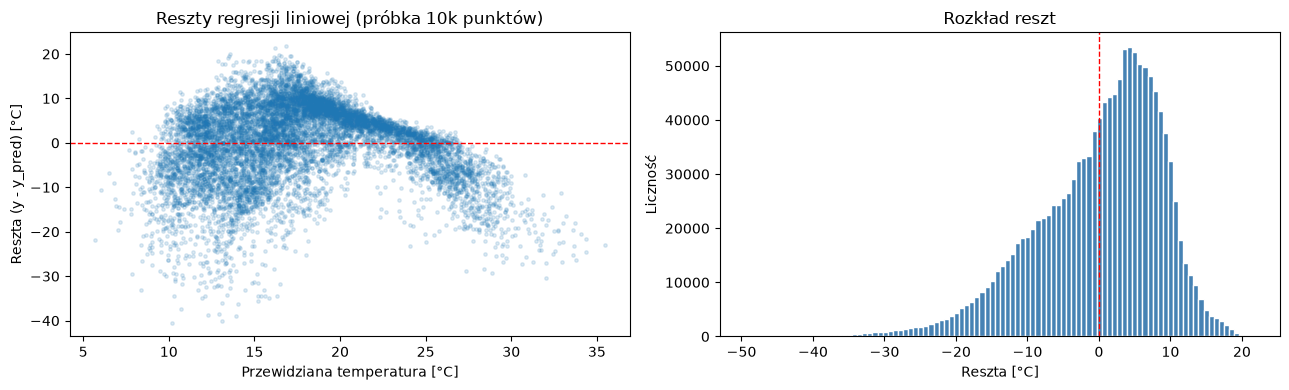

Reszty: mean=+0.0132, std=8.8131, min=-49.49, max=+21.76


In [27]:
import matplotlib.pyplot as plt

y_pred = linreg.predict(X_test)
residuals = y_test.to_numpy() - y_pred

# Wycięto próbkę 10k dla scatterplotu, pełne 1.3M punktów to czarna plama
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(residuals), size=min(10_000, len(residuals)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_pred[sample_idx], residuals[sample_idx], alpha=0.15, s=6)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Przewidziana temperatura [°C]')
axes[0].set_ylabel('Reszta (y - y_pred) [°C]')
axes[0].set_title('Reszty regresji liniowej (próbka 10k punktów)')

axes[1].hist(residuals, bins=100, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Reszta [°C]')
axes[1].set_ylabel('Liczność')
axes[1].set_title('Rozkład reszt')

plt.tight_layout()
plt.show()

print(f'Reszty: mean={residuals.mean():+.4f}, std={residuals.std():.4f}, '
      f'min={residuals.min():+.2f}, max={residuals.max():+.2f}')

# 5. Wnioski

Wynik baseline'u:

DummyRegressor osiąga R2 około 0, punkt odniesienia.

LinearRegression z czterema cechami (`year`, `month`, `lat`, `lon`) osiąga R2 około 0.24 oraz MAE około 7 °C. Model wychwytuje globalny trend (im wyższa szerokość geograficzna, tym chłodniej), ale liniowa zależność nie wystarcza, bo temperatura zmienia się nieliniowo z szerokością (równik vs bieguny) oraz z miesiącem (cykl pór roku).